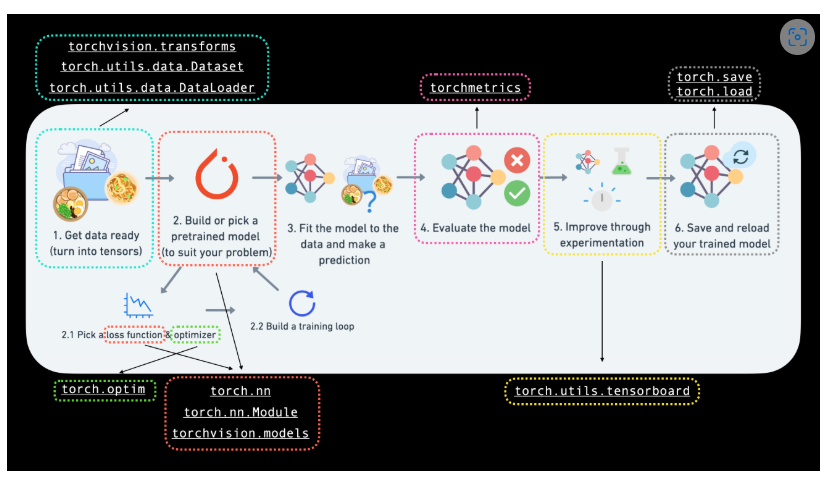

## 0. Computer vision libraries in PyTorch

In [8]:
# Import Pytorch
import torch
from torch import nn

# Import torchvision
import torchvision
from torchvision import models, datasets
from torchvision.transforms import ToTensor

# Import other libraries
import matplotlib.pyplot as plt

In [7]:
# Check version of Pytorch
print("Pytorch version:", torch.__version__)
# Check version of torchvision
print("Torchvision version:", torchvision.__version__)

Pytorch version: 2.5.1+cu124
Torchvision version: 0.20.1+cu124


## 1. Getting a dataset

In [9]:
# Setup training data
train_data = datasets.FashionMNIST(
    root="data", # where to download data to?
    train=True, # get training data
    download=True, # download data if it doesn't exist on disk
    transform=ToTensor(), # images come as PIL format, we want to turn into Torch tensors
    target_transform=None # you can transform labels as well
)

# Setup testing data
test_data = datasets.FashionMNIST(
    root="data",
    train=False, # get test data
    download=True,
    transform=ToTensor()
)

100%|██████████| 26.4M/26.4M [00:28<00:00, 927kB/s] 


Extracting data/FashionMNIST/raw/train-images-idx3-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 29.5k/29.5k [00:00<00:00, 159kB/s]


Extracting data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 4.42M/4.42M [00:15<00:00, 283kB/s] 


Extracting data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 5.15k/5.15k [00:00<00:00, 4.47MB/s]

Extracting data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to data/FashionMNIST/raw



In [10]:
# See first training sample
image, label = train_data[0]
image, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

### 1.1 Input and output shapes of a computer vision model

In [11]:
# What's the shape of the image?
print("Image shape:", image.shape)

Image shape: torch.Size([1, 28, 28])


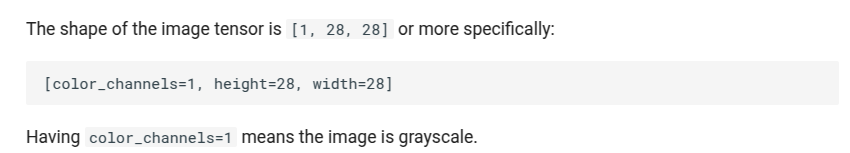

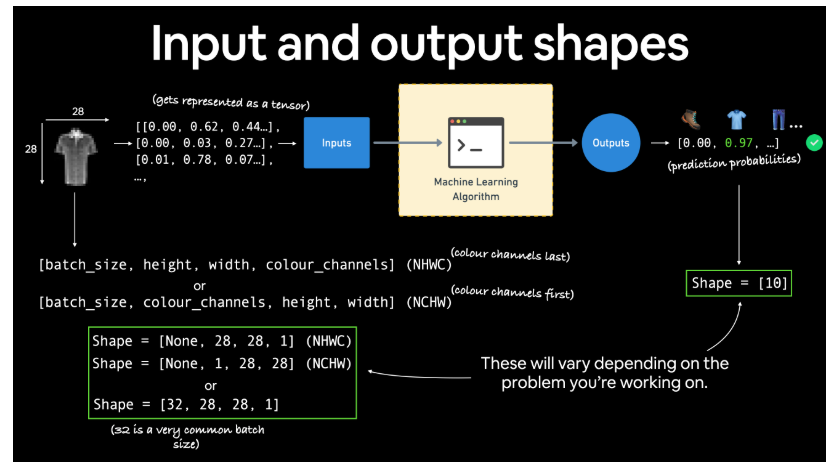

In [12]:
# How many samples are there? 
len(train_data.data), len(train_data.targets), len(test_data.data), len(test_data.targets)

(60000, 60000, 10000, 10000)

In [16]:
# How many classes are there?
class_names = train_data.classes
print("Class names:", class_names)

Class names: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


### 1.2 Visualizing our data

Image shape: torch.Size([1, 28, 28])


Text(0.5, 1.0, '9')

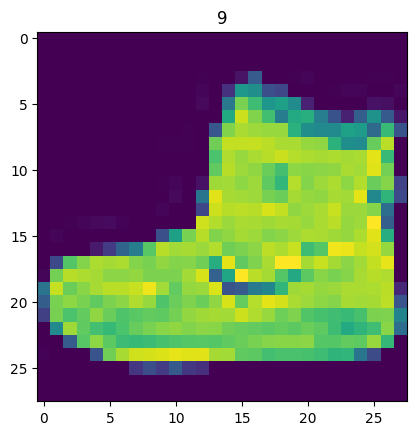

In [19]:
import matplotlib.pyplot as plt
image, label = train_data[0]
print(f"Image shape: {image.shape}")
plt.imshow(image.squeeze()) # image shape is [1, 28, 28] (colour channels, height, width)
plt.title(label)

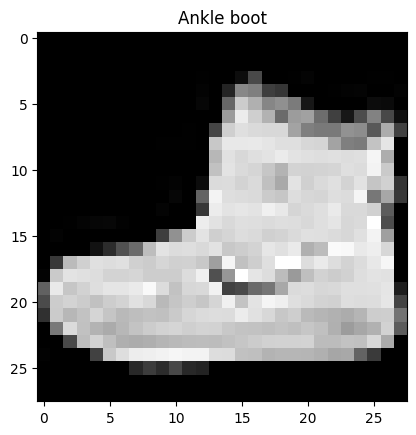

In [ ]:
plt.imshow(image.squeeze(), cmap="gray")
plt.title(class_names[label])

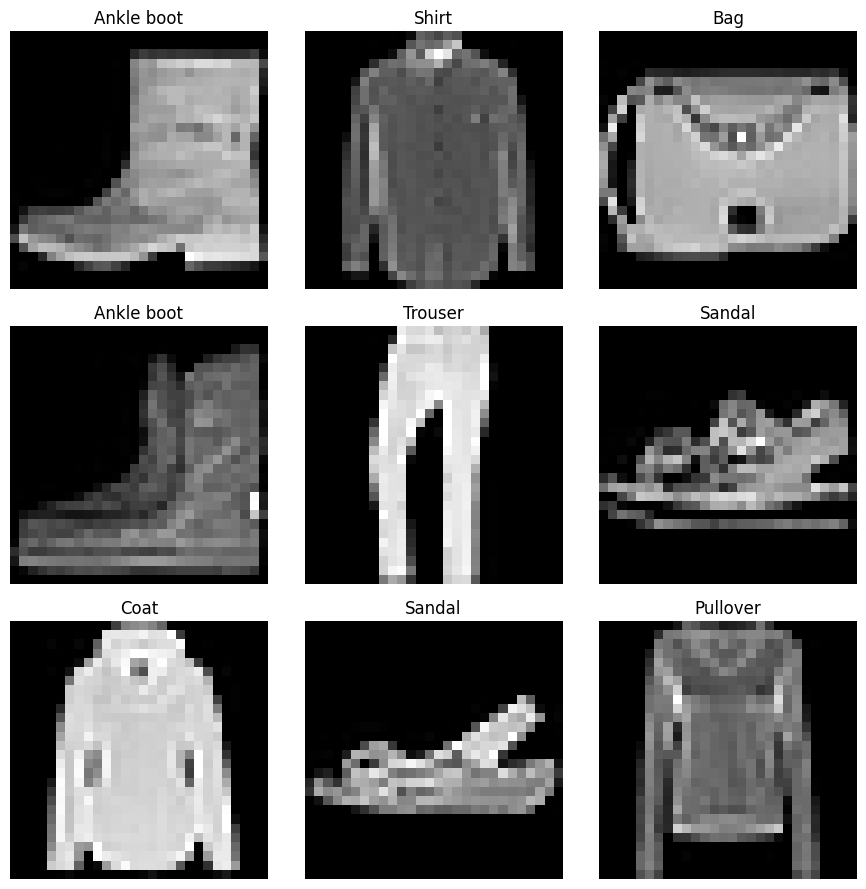

In [21]:
# Plotting a few images
torch.manual_seed(42) # for reproducibility
# Set up figure
plt.figure(figsize=(9, 9))
# Loop through 9 random samples
for i in range(9):
    # Randomly select an index
    rand_idx = torch.randint(0, len(train_data), size=[1]).item()
    # Get the image and label
    image, label = train_data[rand_idx]
    # Plot the image
    plt.subplot(3, 3, i+1)
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis(False)
# Show the plot
plt.tight_layout()
plt.show()

## 2. Prepare DataLoader

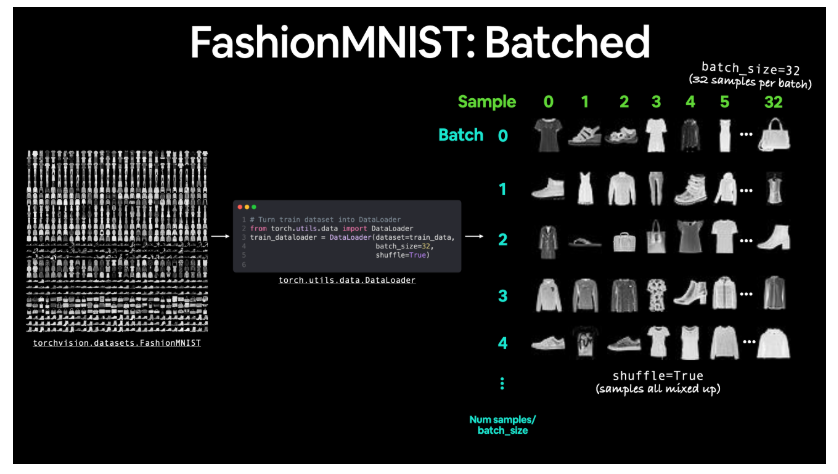

In [22]:
from torch.utils.data import DataLoader

In [23]:
# Setup the batch size hyperparameter
BATCH_SIZE = 32

# Turn datasets into iterables (batches)
train_dataloader = DataLoader(train_data, # dataset to turn into iterable
    batch_size=BATCH_SIZE, # how many samples per batch? 
    shuffle=True # shuffle data every epoch?
)

test_dataloader = DataLoader(test_data,
    batch_size=BATCH_SIZE,
    shuffle=False # don't necessarily have to shuffle the testing data
)

# Let's check out what we've created
print(f"Dataloaders: {train_dataloader, test_dataloader}") 
print(f"Length of train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}")

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x78dec7e4baa0>, <torch.utils.data.dataloader.DataLoader object at 0x78dec7ef1640>)
Length of train dataloader: 1875 batches of 32
Length of test dataloader: 313 batches of 32


In [24]:
# DataLoader iterators
print("First batch of training data:")
train_features, train_labels = next(iter(train_dataloader))
print(f"Features shape: {train_features.shape}")
print(f"Labels shape: {train_labels.shape}")

First batch of training data:
Features shape: torch.Size([32, 1, 28, 28])
Labels shape: torch.Size([32])


Text(0.5, 1.0, 'Sandal')

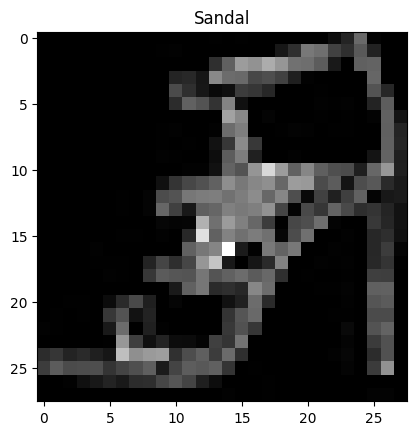

In [ ]:
# Show Sample
plt.imshow(train_features[0].squeeze(), cmap="gray")
plt.title(class_names[train_labels[0]])

## 3. Model 0: Build a baseline model

In [27]:
# Create a flatten layer
flatten_model = nn.Flatten() # all nn modules function as a model (can do a forward pass)

# Get a single sample
x = train_features[0]

# Flatten the sample
output = flatten_model(x) # perform forward pass

# Print out what happened
print(f"Shape before flattening: {x.shape} -> [color_channels, height, width]")
print(f"Shape after flattening: {output.shape} -> [color_channels, height*width]")

# Try uncommenting below and see what happens
#print(x)
#print(output)

Shape before flattening: torch.Size([1, 28, 28]) -> [color_channels, height, width]
Shape after flattening: torch.Size([1, 784]) -> [color_channels, height*width]


The `nn.Flatten()` layer transforms our input shape from [color_channels, height, width] to [color_channels, height*width], flattening the 2D image into a 1D vector for processing by linear layers.

In [42]:
# Create a baseline model

class FashionMNISTModelV0(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        # Define model layers
        self.model = nn.Sequential(
            nn.Flatten(), # flatten the input
            nn.Linear(in_features=input_shape, out_features=hidden_units), # first layer
            # Apply Batch Normalization
            nn.BatchNorm1d(hidden_units), # batch normalization
            nn.ReLU(), # activation function
            nn.Dropout(0.2), # dropout layer
            nn.Linear(in_features=hidden_units, out_features=output_shape), # second layer
            nn.ReLU() # activation function
        )
    def forward(self, x):
        return self.model(x)

In [29]:
torch.manual_seed(42)

# Need to setup model with input parameters
model_0 = FashionMNISTModelV0(input_shape=784, # one for every pixel (28x28)
    hidden_units=10, # how many units in the hidden layer
    output_shape=len(class_names) # one for every class
)
model_0.to("cpu") # keep model on CPU to begin with 

FashionMNISTModelV0(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): BatchNorm1d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): Dropout(p=0.2, inplace=False)
    (5): Linear(in_features=10, out_features=10, bias=True)
  )
)

### 3.1 Setup loss, optimizer and evaluation metrics

In [30]:
import requests
from pathlib import Path 

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  # Note: you need the "raw" GitHub URL for this to work
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

helper_functions.py already exists, skipping download


In [ ]:
# Import accuracy metric
from helper_functions import accuracy_fn # Note: could also use torchmetrics.Accuracy(task = 'multiclass', num_classes=len(class_names)).to(device)

In [35]:
# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss() # this is also called "criterion"/"cost function" in some places
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1, weight_decay=0.01) # stochastic gradient descent

### 3.2 Creating a training loop and training a model on batches of data

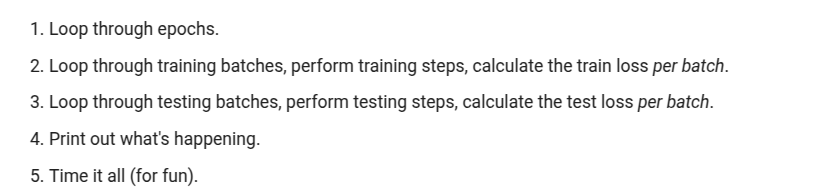

In [39]:
from timeit import default_timer as timer 
def print_train_time(start: float, end: float, device: torch.device = None):
    """Prints difference between start and end time.

    Args:
        start (float): Start time of computation (preferred in timeit format). 
        end (float): End time of computation.
        device ([type], optional): Device that compute is running on. Defaults to None.

    Returns:
        float: time between start and end in seconds (higher is longer).
    """
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

In [43]:
# Import tqdm for progress bar
from tqdm.auto import tqdm


# set the seed for reproducibility
torch.manual_seed(42)
train_time_on_cpu_start = timer()

# Setup epochs
epochs = 3

# Creating the taining and testing loop

for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------")
    # Training
    model_0.train() # put model in training mode
    train_loss = 0

    for batch, (X, y) in enumerate(train_dataloader):
        # Send data to GPU if available
        X, y = X.to("cpu"), y.to("cpu")
        # 1. Forward pass
        y_pred = model_0(X) # make predictions
        # 2. Calculate loss/accuracy
        loss = loss_fn(y_pred, y) # calculate loss
        train_loss += loss.item() # accumulate loss
        # 3. Optimizer zero grad
        optimizer.zero_grad() # zero gradients
        # 4. Loss backwards
        loss.backward() # backpropagation
        # 5. Optimizer step
        optimizer.step() # update weights
    # Calculate train loss and accuracy
    train_loss /= len(train_dataloader) # average loss
    y_pred_labels = torch.argmax(y_pred, dim=1) # get predicted labels
    train_acc = accuracy_fn(y_true=y.cpu(), y_pred=y_pred_labels.cpu()) # calculate accuracy
    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")
    # Testing
    model_0.eval() # put model in evaluation mode
    test_loss = 0
    test_acc = 0
    with torch.inference_mode(): # turn off gradients
        for batch, (X, y) in enumerate(test_dataloader):
            # Send data to GPU if available
            X, y = X.to("cpu"), y.to("cpu")
            # 1. Forward pass
            test_pred = model_0(X) # make predictions
            # 2. Calculate loss/accuracy
            loss = loss_fn(test_pred, y) # calculate loss
            test_loss += loss.item() # accumulate loss
            test_pred_labels = torch.argmax(test_pred, dim=1) # get predicted labels
            test_acc += accuracy_fn(y_true=y.cpu(), y_pred=test_pred_labels.cpu()) # calculate accuracy
        test_loss /= len(test_dataloader) # average loss
        test_acc /= len(test_dataloader) # average accuracy
        print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%")

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
---------
Train loss: 0.80812 | Train accuracy: 71.88%
Test loss: 0.65126 | Test accuracy: 79.50%
Epoch: 1
---------
Train loss: 0.80211 | Train accuracy: 78.12%
Test loss: 0.68425 | Test accuracy: 76.41%
Epoch: 2
---------
Train loss: 0.80208 | Train accuracy: 68.75%
Test loss: 0.72318 | Test accuracy: 76.83%


## 4. Make predictions and get Model 0 results

In [40]:
torch.manual_seed(42)
def eval_model(model: torch.nn.Module, 
               data_loader: torch.utils.data.DataLoader, 
               loss_fn: torch.nn.Module, 
               accuracy_fn):
    """Returns a dictionary containing the results of model predicting on data_loader.

    Args:
        model (torch.nn.Module): A PyTorch model capable of making predictions on data_loader.
        data_loader (torch.utils.data.DataLoader): The target dataset to predict on.
        loss_fn (torch.nn.Module): The loss function of model.
        accuracy_fn: An accuracy function to compare the models predictions to the truth labels.

    Returns:
        (dict): Results of model making predictions on data_loader.
    """
    loss, acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            # Make predictions with the model
            y_pred = model(X)
            
            # Accumulate the loss and accuracy values per batch
            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_true=y, 
                                y_pred=y_pred.argmax(dim=1)) # For accuracy, need the prediction labels (logits -> pred_prob -> pred_labels)
        
        # Scale loss and acc to find the average loss/acc per batch
        loss /= len(data_loader)
        acc /= len(data_loader)
        
    return {"model_name": model.__class__.__name__, # only works when model was created with a class
            "model_loss": loss.item(),
            "model_acc": acc}

# Calculate model 0 results on test dataset
model_0_results = eval_model(model=model_0, data_loader=test_dataloader,
    loss_fn=loss_fn, accuracy_fn=accuracy_fn
)
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.7466233968734741,
 'model_acc': 77.35623003194888}

## Model 2: Building a Convolutional Neural Network (CNN)

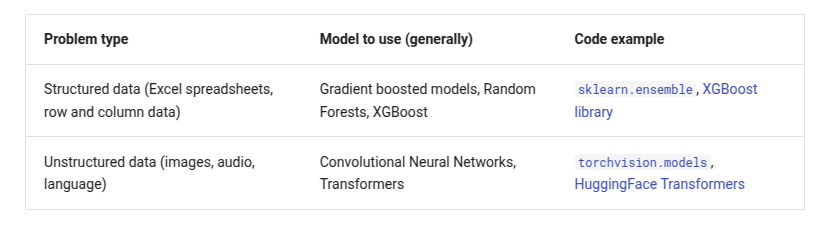

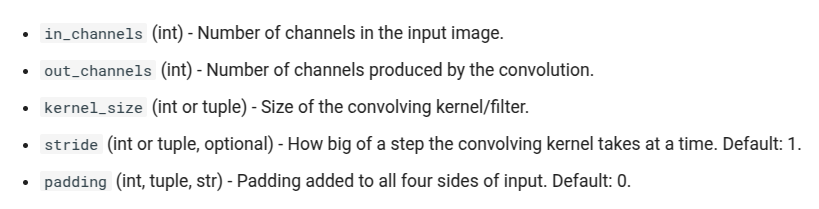

In [55]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = "cpu"):
    train_loss, train_acc = 0, 0
    model.to(device)
    for batch, (X, y) in enumerate(data_loader):
        # Send data to GPU
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss
        train_acc += accuracy_fn(y_true=y,
                                 y_pred=y_pred.argmax(dim=1)) # Go from logits -> pred labels

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

    # Calculate loss and accuracy per epoch and print out what's happening
    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")

def test_step(data_loader: torch.utils.data.DataLoader,
              model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = "cpu"):
    test_loss, test_acc = 0, 0
    model.to(device)
    model.eval() # put model in eval mode
    # Turn on inference context manager
    with torch.inference_mode(): 
        for X, y in data_loader:
            # Send data to GPU
            X, y = X.to(device), y.to(device)
            
            # 1. Forward pass
            test_pred = model(X)
            
            # 2. Calculate loss and accuracy
            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y_true=y,
                y_pred=test_pred.argmax(dim=1) # Go from logits -> pred labels
            )
        
        # Adjust metrics and print out
        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
        print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")

In [64]:
class FashionMNISTModelV2(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        # Define model layers
        self.conv_block = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=10, kernel_size=3, stride=1), # 1 input channel (greyscale), 10 output channels (filters), 3x3 kernel
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # reduce size by half
            nn.Conv2d(in_channels=10, out_channels=20, kernel_size=3, stride=1), # 10 input channels (from previous layer), 20 output channels (filters)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2) # reduce size by half
        )
        self.fc_layer = nn.Sequential(
            nn.Flatten(), # flatten the input
            nn.Linear(in_features=500, out_features=hidden_units), # first layer (20 channels * 5 * 5 = 500)
            # Apply Batch Normalization
            nn.BatchNorm1d(hidden_units), # batch normalization
            nn.ReLU(), # activation function
            nn.Dropout(0.5), # dropout layer
            nn.Linear(in_features=hidden_units, out_features=output_shape), # second layer
            nn.ReLU() # activation function
        )

    def forward(self, x):
        x = self.conv_block(x)
        x = self.fc_layer(x)
        return x

In [65]:
torch.manual_seed(42)
# Need to setup model with input parameters
model_2 = FashionMNISTModelV2(input_shape=1, # one for every pixel (28x28)
    hidden_units=10, # how many units in the hidden layer
    output_shape=len(class_names) # one for every class
)
model_2

FashionMNISTModelV2(
  (conv_block): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(10, 20, kernel_size=(3, 3), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layer): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=500, out_features=10, bias=True)
    (2): BatchNorm1d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): Dropout(p=0.5, inplace=False)
    (5): Linear(in_features=10, out_features=10, bias=True)
    (6): ReLU()
  )
)

In [66]:
# Setup loss and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(), 
                             lr=0.1, weight_decay=0.01) # stochastic gradient descent

In [67]:
torch.manual_seed(42)

# Train and test the model

for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------")
    # Training
    model_2.train() # put model in training mode
    train_loss = 0
    for batch, (X, y) in enumerate(train_dataloader):
        # Send data to GPU if available
        X, y = X.to("cpu"), y.to("cpu")
        # 1. Forward pass
        y_pred = model_2(X) # make predictions
        # 2. Calculate loss/accuracy
        loss = loss_fn(y_pred, y) # calculate loss
        train_loss += loss.item() # accumulate loss
        # 3. Optimizer zero grad
        optimizer.zero_grad() # zero gradients
        # 4. Loss backwards
        loss.backward() # backpropagation
        # 5. Optimizer step
        optimizer.step() # update weights
    # Calculate train loss and accuracy
    train_loss /= len(train_dataloader) # average loss
    y_pred_labels = torch.argmax(y_pred, dim=1) # get predicted labels
    train_acc = accuracy_fn(y_true=y.cpu(), y_pred=y_pred_labels.cpu()) # calculate accuracy
    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")
    # Testing
    model_2.eval() # put model in evaluation mode
    test_loss = 0
    test_acc = 0
    with torch.inference_mode(): # turn off gradients
        for batch, (X, y) in enumerate(test_dataloader):
            # Send data to GPU if available
            X, y = X.to("cpu"), y.to("cpu")
            # 1. Forward pass
            test_pred = model_2(X) # make predictions
            # 2. Calculate loss/accuracy
            loss = loss_fn(test_pred, y) # calculate loss
            test_loss += loss.item() # accumulate loss
            test_pred_labels = torch.argmax(test_pred, dim=1) # get predicted labels
            test_acc += accuracy_fn(y_true=y.cpu(), y_pred=test_pred_labels.cpu()) # calculate accuracy
        test_loss /= len(test_dataloader) # average loss
        test_acc /= len(test_dataloader) # average accuracy
        print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%")


  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
---------
Train loss: 1.38866 | Train accuracy: 62.50%
Test loss: 0.98128 | Test accuracy: 66.49%
Epoch: 1
---------
Train loss: 1.31222 | Train accuracy: 59.38%
Test loss: 0.96507 | Test accuracy: 68.66%
Epoch: 2
---------
Train loss: 1.30148 | Train accuracy: 37.50%
Test loss: 1.02641 | Test accuracy: 70.98%
